# py-Monocle3 tutorial — small synthetic

Full pipeline: `preprocess_cds → reduce_dimension → cluster_cells → learn_graph → order_cells → plot_cells`.

## 1. Setup

In [1]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import pymonocle3 as m3
import pymonocle3
print(f'pymonocle3 {pymonocle3.__version__}')

pymonocle3 0.1.0


## 2. Build a small bifurcation dataset

In [2]:
rng = np.random.RandomState(0)
n_stem, n_b1, n_b2 = 100, 100, 100
n_genes = 200
pt = np.concatenate([np.linspace(0, 0.5, n_stem), np.linspace(0.5, 1, n_b1), np.linspace(0.5, 1, n_b2)])
branch = np.array(['stem']*n_stem + ['B1']*n_b1 + ['B2']*n_b2)
counts = rng.poisson(2.0, (n_stem + n_b1 + n_b2, n_genes)).astype(np.float32)
# stem-up genes
for c in range(n_stem):
    counts[c, :30] += rng.poisson(5 * (0.5 - pt[c]), 30)
# B1 markers
for c in range(n_stem, n_stem + n_b1):
    counts[c, 30:50] += rng.poisson(10 * (pt[c] - 0.5), 20)
# B2 markers
for c in range(n_stem + n_b1, len(pt)):
    counts[c, 50:70] += rng.poisson(10 * (pt[c] - 0.5), 20)

adata = ad.AnnData(X=counts)
adata.obs['true_pt'] = pt
adata.obs['true_branch'] = branch
adata.obs_names = [f'c{i}' for i in range(len(pt))]
adata.var_names = [f'g{i}' for i in range(n_genes)]
print('AnnData:', adata.shape)

AnnData: (300, 200)


## 3. Run the pipeline

In [3]:
m3.estimate_size_factors(adata)
m3.preprocess_cds(adata, num_dim=20)
m3.reduce_dimension(adata, max_components=2, umap_min_dist=0.1)
m3.cluster_cells(adata)
m3.learn_graph(adata)
# Pick root: cell with lowest true pseudotime
root = adata.obs_names[int(np.argmin(pt))]
m3.order_cells(adata, root_cells=[root])
print('Done. Inferred pseudotime range:', adata.obs.get('pseudotime', adata.obs.get('Pseudotime', 'n/a')))

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/umap/umap_.py:2021: UserWarning: precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.
  warn(


Done. Inferred pseudotime range: n/a


## 4. Plot UMAP coloured by true vs inferred state

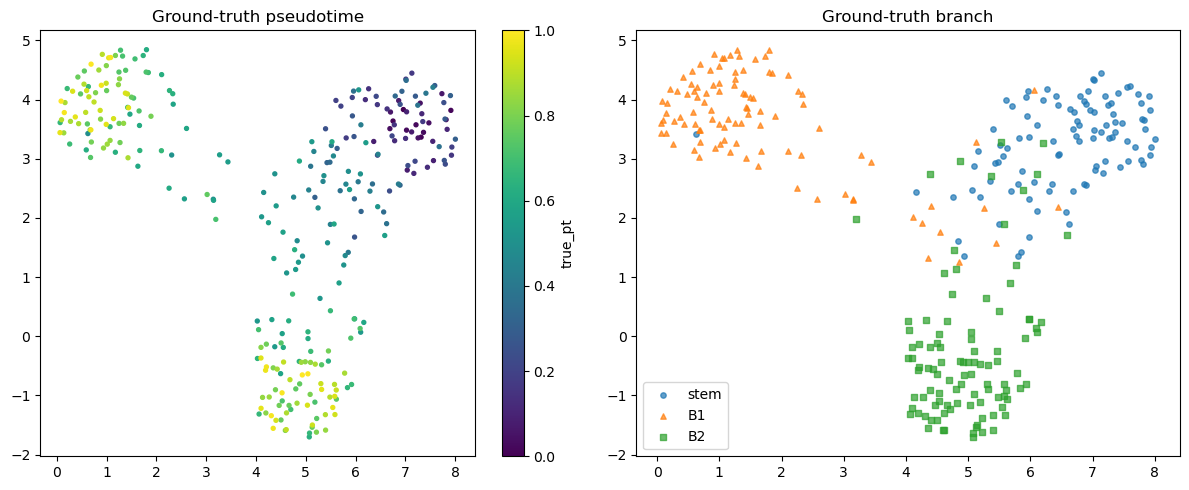

In [4]:
umap = adata.obsm['X_umap']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sc = ax1.scatter(umap[:,0], umap[:,1], c=adata.obs['true_pt'], s=8, cmap='viridis')
plt.colorbar(sc, ax=ax1, label='true_pt'); ax1.set_title('Ground-truth pseudotime')
for b, mk_ in zip(['stem','B1','B2'], 'o^s'):
    mask = adata.obs['true_branch'] == b
    ax2.scatter(umap[mask,0], umap[mask,1], s=15, marker=mk_, label=b, alpha=0.7)
ax2.legend(); ax2.set_title('Ground-truth branch')
plt.tight_layout(); plt.show()

## 5. `plot_cells` from Bio-Babel/Monocle3-python (ggplot2-python output)

Saving 6 x 5 in image to monocle3_cluster.png


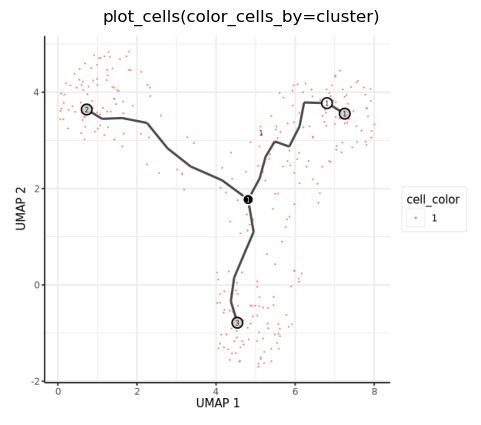

In [5]:
from ggplot2_py import ggsave
from PIL import Image
try:
    p = m3.plot_cells(adata, color_cells_by='cluster')
    ggsave('monocle3_cluster.png', plot=p, width=6, height=5, dpi=100)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.imshow(Image.open('monocle3_cluster.png')); ax.axis('off'); ax.set_title('plot_cells(color_cells_by=cluster)')
    plt.show()
except Exception as e:
    print('plot_cells error:', e)